# utils

In [19]:
import jax.numpy as jnp
def hessian_fd(u, x, h):
    """
    Central‐difference Hessian of u at x = [x0,x1]:
      returns a 2×2 array H where
        H[0,0] ≈ ∂²u/∂x0²,
        H[1,1] ≈ ∂²u/∂x1²,
        H[0,1] = H[1,0] ≈ ∂²u/∂x0∂x1.
    """
    x0, x1 = x[0], x[1]
    # points for mixed derivative
    f_pp = u(jnp.array([x0 + h, x1 + h]))
    f_pm = u(jnp.array([x0 + h, x1 - h]))
    f_mp = u(jnp.array([x0 - h, x1 + h]))
    f_mm = u(jnp.array([x0 - h, x1 - h]))
    # pure second derivatives
    f_xp = u(jnp.array([x0 + h, x1]))
    f_xm = u(jnp.array([x0 - h, x1]))
    f_yp = u(jnp.array([x0, x1 + h]))
    f_ym = u(jnp.array([x0, x1 - h]))
    f_c  = u(jnp.array([x0,     x1    ]))
    
    u_xx = (f_xp - 2*f_c + f_xm) / (h*h)
    u_yy = (f_yp - 2*f_c + f_ym) / (h*h)
    u_xy = (f_pp - f_pm - f_mp + f_mm) / (4*h*h)
    
    return jnp.array([[u_xx, u_xy],
                      [u_xy, u_yy]])

def hessian_fd_partial(u, h):
    """
    Returns a function that computes the Hessian of u at x using finite differences.
    """
    def hessian_at_x(x):
        return hessian_fd(u, x, h)
    return hessian_at_x

# RandSVD

In [10]:

# HVP for single point and single direction from Bachelier
def hvp(f, x, v):
    return jax.jvp(lambda x_: eqx.filter_grad(f)(x_), (x,), (v,))[1]


# this is a version where we explicitly add a list of boolean values, indicating whether we should compute the hvp for that direction
# TODO isnt this the same as just setting the undesired directions to 0? Then we could just use the normal hvp_batch function
def hvp_cond(f, x, v, eval_hvp):                                   #jnp.zeros(shape=(x.shape[-1],))
    return jax.lax.cond(eval_hvp, lambda _: hvp(f, x, v), lambda _: jnp.zeros_like(v), None)



# from bachelier
def hvp_batch(f, inputs, directions):
    """
    Compute Hessian-vector products: H(x_i) @ v_j
    Args:
        f: scalar-valued function f: R^n -> R
        inputs: [num_inputs, input_dim]
        directions: [num_directions, input_dim]
    Returns:
        hvps: [num_inputs, num_directions, input_dim]
    """
    def hvp_fn(x, v):
        return hvp(f, x, v)
    batched = eqx.filter_vmap(eqx.filter_vmap(hvp_fn, in_axes=(0, None)), in_axes=(None, 0))
    return jnp.transpose(batched(inputs, directions), (1, 0, 2))



def hvp_batch_cond(f, inputs, directions, eval_hvp):
    """
    Compute Hessian-vector products: H(x_i) @ v_j ifff eval_hvp[j] == True
    Args:
        f: scalar-valued function f: R^n -> R
        inputs: [num_inputs, input_dim]
        directions: [num_directions, input_dim]
        eval_hvp: [num_directions] boolean array
            if True, compute H(x_i) @ v_j
            if False, return 0
    Returns:
        hvps: [num_inputs, num_directions, input_dim]
            where hvps[i, j] = np.zeros if eval_hvp[j] == False
    """
    def hvp_cond_fn(x, v, eval_hvp):
        return hvp_cond(f, x, v, eval_hvp)
    batched = eqx.filter_vmap(eqx.filter_vmap(hvp_cond_fn, in_axes=(0, None, None)), in_axes=(None, 0, 0))
    return jnp.transpose(batched(inputs, directions, eval_hvp), (1, 0, 2))




# TODO put cfd stuff this somewhere else, separate file?
def cfd_fn(f, h, x, *args):
    
    def cfd_(direction):
      #jax.debug.print("in cfd_ direction.shape: {shape}", shape=direction.shape)
      
      xph = x + h * direction 
      xmh = x - h * direction 
      fd_of_f = (f(xph, *args) - f(xmh, *args)) / (2 * h)

      #jax.debug.print("in cfd_ fd_of_f.shape: {fd}", fd=fd_of_f.shape)
      return fd_of_f
    
    return cfd_




def cfd_cond_fn(f, batch_size):
    def cfd_cond_(direction, eval_hvp):
        return jax.lax.cond(eval_hvp, lambda direction: f(direction), lambda _: jnp.zeros(shape=(batch_size, direction.shape[-1])), direction)
        
    return eqx.filter_vmap(cfd_cond_, in_axes=(0, 0))




In [11]:
def normalize_vectors(vectors):
    return vectors / jnp.linalg.norm(vectors, axis=1, keepdims=True)

#def generate_random_vectors(k, dim, key, normalize=True):
#    key, subkey = jax.random.split(key)
#    vectors = jax.random.normal(subkey, shape=(k, dim))
#    if normalize:
#        vectors = normalize_vectors(vectors)
#    return vectors



def generate_random_vectors(shape, key, normalize=True):
   key, subkey = jax.random.split(key)
   vectors = jax.random.normal(subkey, shape=shape)
   if normalize:
       vectors = normalize_vectors(vectors)
   return vectors

In [12]:
# TODO clean up

def get_rand_SVD_directions(f, x, k, key, normalized, oversampling=3, kappa=0.95):

    
    #dim = x.shape[-1]
    #sketch_directions = generate_random_vectors(k, dim, key) # (k, dim)
    
    #sketch_directions = jrandom.normal(key, shape=(k, ref_model.n_dims))
    sketch_directions = generate_random_vectors(shape=(k, ref_model.n_dims), key=key)
    
    
    
    # if f = price function, not model
    if normalized:
        sketch_directions = sketch_directions.reshape(k, *ref_model.un_flattened_shape)
        dirs_scaled = sketch_directions * ref_model.x_std[None, :, :] # (k, basket, 2)
        #jax.debug.print("scaled.shape {shape}", shape=dirs_scaled.shape)    
        dirs_scaled_flat  = dirs_scaled.reshape(k, ref_model.n_dims) # (k, 2*basket)
        #jax.debug.print("flat.shape {shape}", shape=dirs_scaled_flat.shape)
        sketch_directions = dirs_scaled_flat
    
    #jax.debug.print("sd.shape {shape}", shape=sketch_directions.shape)
    #return sketch_directions, None, None, None

   
    ## Step 1: build sketch Y = H @ sketch_directions
    #Y = hvp_batch(f=f, inputs=x, directions=sketch_directions) # (batch_size, k, dim)
    ##jax.debug.print("Y.shape {shape}", shape=Y.shape)
    ## TODO understand if averaging over batch_size is the correct approach
    #Y = jnp.mean(Y, axis=0)  # (k, dim)
    #Y = Y.T # (dim, k)
    ##jax.debug.print("Y.shape {shape}", shape=Y.shape)


    Y = hvp_batch(
        f=f,
        inputs=x, 
        directions=sketch_directions
    ) # (batch, k, 2*basket)
    #jax.debug.print("Y.shape {shape}", shape=Y.shape)
    # TODO re-normalize here ????
   
    Y = jnp.mean(Y, axis=0)  # (k, dim)
    Y = Y.T # (2*basket, k)
    #jax.debug.print("Y.shape {shape}", shape=Y.shape)
    #return sketch_directions.reshape(k, basket_dim, 2), None, None

    
    ## power iterated version of step 1
    #Y = hvp_power_iterated_sketch(f=f, x=x, sketch_directions=sketch_directions, q=3) # (k, dim)
    #Y = Y.T # (dim, k)
    
    
    
    # Step 2: orthonormalize Y
    # TODO breaks when k > dim, which I guess makes sense
    # TODO how to oversample then?
    Q, _ = jnp.linalg.qr(Y) # (*2basket, k)  
    #jax.debug.print("Q.shape {shape}", shape=Q.shape)
    #return sketch_directions.reshape(k, basket_dim, 2), None, None





    ## Step 3: each row of B is H @ q_i
    #B_rows = hvp_batch(f=f, inputs=x, directions=Q.T) # (batch_size, k, dim)
    ##jax.debug.print("B_rows.shape {shape}", shape=B_rows.shape)  
    ## TODO understand if averaging over batch_size is the correct approach
    #B_rows = jnp.mean(B_rows, axis=0) # (k, dim)
    ##jax.debug.print("B_rows.shape {shape}", shape=B_rows.shape)
    #B = jnp.stack(B_rows, axis=0) # (k, dim)
    ##jax.debug.print("B.shape {shape}", shape=B.shape)


    B_rows = hvp_batch(
        f=f,
        inputs=x, 
        directions=Q.T
    ) # (batch, k, in_dim)
    #jax.debug.print("B_rows.shape {shape}", shape=B_rows.shape)

    B_rows = jnp.mean(B_rows, axis=0)  # (k, in_dimm)
    B = jnp.stack(B_rows, axis=0) # (k, in_dimm)
    #jax.debug.print("B.shape {shape}", shape=B.shape)
    



    # Step 4: SVD on B
    U_tilde, S, Vt = jnp.linalg.svd(B, full_matrices=False) # (k, k)
    #jax.debug.print("U_tilde.shape {shape}", shape=U_tilde.shape)
   


    # Step 5: Lift back U = Q @ U_tilde
    U = Q @ U_tilde  # (2*basket, k)
    U = U.T # (k, 2*basket)
    #jax.debug.print("U.shape {shape}", shape=U.shape)

    # TODO re-normalize here ????

    
    S_var = S**2 / jnp.sum(S**2)
    eval_dir = (~(jnp.cumsum(S_var) > kappa)).at[0].set(True) # make use that at least the first principal component is always actively used
    k_dir = jnp.sum(eval_dir) # number of principal components used
    
    return U.reshape(k, *ref_model.un_flattened_shape), eval_dir, k_dir, S_var
    #return U.reshape(ref_model.n_dims, *ref_model.un_flattened_shape), eval_dir, k_dir, S_var


# Bratu Solid Fuel Ignition

In [13]:
import matplotlib.pyplot as plt
def plot_3d_data(x1, x2, y, x1_label, x2_label, y_label, title=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x1, x2, y, c=y, cmap=plt.cm.viridis)

    # Add a colorbar to show the mapping of colors to z-values
    cbar = fig.colorbar(sc)
    cbar.set_label(y_label)
    
    ax.set_title(title if title else '3D Scatter Plot')
    ax.set_xlabel(x1_label)
    ax.set_ylabel(x2_label)
    ax.set_zlabel(y_label)
    return fig


In [31]:
import jax
import jax.numpy as jnp
from jaxtyping import PRNGKeyArray
import equinox as eqx
from functools import partial


class SFI_Bratu(eqx.Module):


    key: PRNGKeyArray

    n_dims: int
    un_flattened_shape: tuple
    

    s: int  # number of grid intervals per axis
    h: float  # grid spacing = 1/s
    lam: float  # reaction parameter
    tol_res: float  # tolerance for residual norm
    tol_cg: float  # tolerance for CG linear solver
    maxiter_cg: int  # max CG iterations
    maxiter_newton: int  # max Newton iterations

    y_int: jnp.ndarray  # interior solution vector of length (s-1)^2
    y_full: jnp.ndarray  # full solution vector of length s^2

    def __init__(self, key, s=10, lam=6.0, tol_res=1e-6, tol_cg=1e-6, maxiter_cg=500, maxiter_newton=500):

        self.key = key

        self.n_dims = 2
        self.un_flattened_shape = (2,)

        self.s = s
        self.h = 1.0/s
        self.lam = lam
        self.tol_res = tol_res
        self.tol_cg = tol_cg
        self.maxiter_cg = maxiter_cg
        self.maxiter_newton = maxiter_newton

        print("Solving...")
        N = (self.s-1)**2
        y0 = jnp.zeros(N)
        self.y_int = self.newton_solve(y0)
        self.y_full = self.build_full(self.y_int)

    # 1) Build the discrete Bratu residual F(y)
    def bratu_residual(self, y, lam, h, s):
        """
        y     : vector of length (s-1)^2 containing interior nodes y_{i,j}
        lam   : reaction parameter \lambda
        h     : grid spacing = 1/s
        s     : number of grid intervals per axis
        Returns: residual vector of length (s-1)^2
        """
        # reshape to 2D interior
        y_int = y.reshape((s-1, s-1))
        # build full grid with Dirichlet BCs
        y_full = jnp.zeros((s+1, s+1))
        y_full = y_full.at[1:-1, 1:-1].set(y_int)

        # right boundary x0=1 -> y=1
        #y_full = y_full.at[-1, :].set(1.0)
        # other boundaries remain zero

        # apply 5-point Laplacian at interior
        lap = (
            y_full[2:, 1:-1] + y_full[:-2, 1:-1]
            + y_full[1:-1, 2:] + y_full[1:-1, :-2]
            - 4.0 * y_full[1:-1, 1:-1]
        ) / (h * h)

        # residual = Laplacian - lam * exp(y)
        res_int = -lap - lam * jnp.exp(y_int)
        return res_int.reshape(-1)


    # 2) Tangent-linear (Jacobian-vector) via jax.jvp
    def F_tangent(self, y, y_dot, lam, h, s):
        """
        Returns (F(y), J(y) @ y_dot) using forward-mode autodiff
        """
        return jax.jvp(lambda yy: self.bratu_residual(yy, lam, h, s), (y,), (y_dot,))

    # 3) Matrix-free CG to solve J dx = -F(y)
    def cg_step(self, y):
        """
        Solve J dx = -F(y) approximately via CG, matrix-free.
        F_tangent supplies mat-vecs.
        """
        # initial guess dx=0
        dx = jnp.zeros_like(y)
        Fy = self.bratu_residual(y, self.lam, self.h, self.s)
        # directional derivative at zero = zero
        _, Jdx = self.F_tangent(y, dx, self.lam, self.h, self.s)
        r = - Fy - Jdx
        p = r
        rr = jnp.dot(r, r)

        def cond(state):
            i, dx, r, p, rr = state
            return (i < self.maxiter_cg) & (rr > self.tol_cg * self.tol_cg)

        def body(state):
            i, dx, r, p, rr = state
            # Jacobian-vector
            _, Jp = self.F_tangent(y, p, self.lam, self.h, self.s)
            alpha = rr / (jnp.dot(p, Jp) + 1e-16)
            dx_new = dx + alpha * p
            r_new = r - alpha * Jp
            rr_new = jnp.dot(r_new, r_new)
            beta = rr_new / (rr + 1e-16)
            p_new = r_new + beta * p
            return (i + 1, dx_new, r_new, p_new, rr_new)

        init = (0, dx, r, p, rr)
        _, dx_final, _, _, _ = jax.lax.while_loop(cond, body, init)
        return dx_final

    # 4) Newton solver using cg_step

    def newton_solve(self, y0):
        """
        Solve F(y)=0 via inexact Newton (Newton + matrix-free CG)
        y0         : initial interior guess vector
        lam, h, s  : PDE params
        tol_res    : stopping tolerance on ||F(y)||
        tol_cg     : CG tolerance for linear solves
        """
        def body(state):
            y, _, it = state
            Fy = self.bratu_residual(y, self.lam, self.h, self.s)
            dx = self.cg_step(y)
            y_new = y + dx
            norm = jnp.linalg.norm(Fy)
            return (y_new, norm, it+1)

        def cond(state):
            y, norm, iter = state
            return (norm > self.tol_res) & (iter < self.maxiter_newton)

        init = (y0, jnp.inf, 0)
        y_final, _, _ = jax.lax.while_loop(cond, body, init)
        return y_final

    # 5) Build full grid from interior solution
    def build_full(self, y_int):
        y_full = jnp.zeros((self.s+1, self.s+1))
        y_full = y_full.at[1:-1, 1:-1].set(y_int.reshape((self.s-1, self.s-1)))

        #y_full = y_full.at[-1, :].set(1.0)
        return y_full

    
    def _cubic_kernel(self, t):
        """
        Cubic convolution kernel (Catmull–Rom with a = -0.5).
        t: distance (can be positive or negative)
        returns: weight
        """
        a = -0.5
        abs_t = jnp.abs(t)
        abs_t2 = abs_t**2
        abs_t3 = abs_t**3
        return jnp.where(
            abs_t <= 1,
            (a+2)*abs_t3 - (a+3)*abs_t2 + 1,
            jnp.where(
                abs_t < 2,
                a*abs_t3 - 5*a*abs_t2 + 8*a*abs_t - 4*a,
                0.0
            )
        )

    

    def interpolate_bicubic(self, y_int, x):
        """
        Bicubic interpolation of the solution on [0,1]^2.
        y_int:  (s-1)^2 interior values
        x:      [x0, x1], the query point in [0,1]^2
        returns: scalar u(x0,x1)
        """
        s = self.s
        y_full = self.build_full(y_int)      # shape (s+1, s+1), all BCs = 0

        # physical → grid coordinates
        u = x[0] * s  
        v = x[1] * s  

        # base cell
        i0 = jnp.floor(u).astype(int)
        j0 = jnp.floor(v).astype(int)

        # fractional offsets in [0,1)
        tx = u - i0
        ty = v - j0

        # we need neighbors at i0-1, i0, i0+1, i0+2 (same for j)
        # define relative offsets
        rel = jnp.array([-1, 0, +1, +2])

        # distances from the sample point to neighbor grid nodes
        # e.g. at i0-1 the distance is (tx + 1), at i0+2 it's (tx - 2), etc.
        dx = tx - rel
        dy = ty - rel

        # vectorize so we can pass a length‑4 array of t’s
        _cubic_weights = jax.vmap(self._cubic_kernel, in_axes=0, out_axes=0)
    
        # compute the 1‑D cubic weights
        wx = _cubic_weights(dx)   # shape (4,)
        wy = _cubic_weights(dy)   # shape (4,)

        # clamp indices so we stay on [0,s]
        ix = jnp.clip(i0 + rel, 0, s)
        jy = jnp.clip(j0 + rel, 0, s)

        # extract the 4×4 patch
        # patch[k,l] = y_full[ix[k], jy[l]]
        patch = y_full[ix[:, None], jy[None, :]]   # shape (4,4)

        # do the outer‑product sum
        return jnp.sum(wx[:, None] * patch * wy[None, :])

    # 6) interpolation
    def interpolate(self, y_int, x):
        #return self.interpolate_bicubic(y_int, x)
        """
        Bilinear interpolate the full grid solution at point x = [x0, x1]
        """
        s=self.s
        y_full = self.y_full
        u = x[0] * s  # x0/h
        v = x[1] * s  # x1/h
        i = jnp.clip(jnp.floor(u).astype(int), 0, s-1)
        j = jnp.clip(jnp.floor(v).astype(int), 0, s-1)
        fu = u - i
        fv = v - j
        
        y00 = y_full[i,   j]
        y10 = y_full[i+1, j]
        y01 = y_full[i,   j+1]
        y11 = y_full[i+1, j+1]
        
        return (1-fu)*(1-fv)*y00 + fu*(1-fv)*y10 + (1-fu)*fv*y01 + fu*fv*y11

     
     
     
    #  7) Pointwise solver returning y(x0,x1)
    def y_of_x(self, x):
        """
        x   : array([x0, x1]) in [0,1]^2
        lam : reaction parameter
        Returns: scalar y(x0,x1)
        """
        return self.interpolate(self.y_int, x)


    def ref_fn(self, x):
        return self.y_of_x(x)
    
    def reference_fn(self, *args):
        return self.ref_fn


    def compute_grid_hessians(self, y_int, build_full, s):
        """
        Compute finite-difference second derivatives on the full (s+1)x(s+1) grid.
        Returns interior arrays uxx, uyy, uxy of shape (s-1, s-1).
        """
        # Reconstruct full solution including boundaries
        y_full = build_full(y_int)
        h = 1.0 / s

        # Pure second derivatives (interior only)
        uxx = (y_full[2:, 1:-1] - 2 * y_full[1:-1, 1:-1] + y_full[:-2, 1:-1]) / (h * h)
        uyy = (y_full[1:-1, 2:] - 2 * y_full[1:-1, 1:-1] + y_full[1:-1, :-2]) / (h * h)

        # Mixed derivative (interior only)
        uxy = (
            y_full[2:, 2:] - y_full[2:, :-2]
          - y_full[:-2, 2:] + y_full[:-2, :-2]
        ) / (4 * h * h)

        return uxx, uyy, uxy

    def hessian_fd_at_point(self, x, uxx, uyy, uxy, s):
        """
        Bilinearly interpolate the grid-Hessian arrays at point x = [x0, x1].
        x0, x1 in [0,1].
        Returns a 2x2 Hessian matrix.
        """
        # Map physical to grid coordinates
        u = x[0] * s
        v = x[1] * s

        # We only have interior values in uxx of shape (s-1, s-1) at grid indices 1..s-1
        # So floor index i, j runs from 1 to s-2
        i = jnp.clip(jnp.floor(u).astype(int), 1, s-2)
        j = jnp.clip(jnp.floor(v).astype(int), 1, s-2)

        fu = u - i
        fv = v - j

        # Bilinear weights
        w00 = (1 - fu) * (1 - fv)
        w10 = fu * (1 - fv)
        w01 = (1 - fu) * fv
        w11 = fu * fv

        # Sample the 2x2 patch from each second-derivative array
        # Note: these arrays are indexed 0..s-2 for interior; offset by -1
        i0, j0 = i - 1, j - 1
        uxx00 = uxx[i0,   j0]
        uxx10 = uxx[i0+1, j0]
        uxx01 = uxx[i0,   j0+1]
        uxx11 = uxx[i0+1, j0+1]

        uyy00 = uyy[i0,   j0]
        uyy10 = uyy[i0+1, j0]
        uyy01 = uyy[i0,   j0+1]
        uyy11 = uyy[i0+1, j0+1]

        uxy00 = uxy[i0,   j0]
        uxy10 = uxy[i0+1, j0]
        uxy01 = uxy[i0,   j0+1]
        uxy11 = uxy[i0+1, j0+1]

        # Interpolate values
        uxx_val = w00*uxx00 + w10*uxx10 + w01*uxx01 + w11*uxx11
        uyy_val = w00*uyy00 + w10*uyy10 + w01*uyy01 + w11*uyy11
        uxy_val = w00*uxy00 + w10*uxy10 + w01*uxy01 + w11*uxy11

        # Build symmetric Hessian
        return jnp.array([[uxx_val, uxy_val],
                          [uxy_val, uyy_val]])

 
    # Example usage inside your workflow:
    # 1) After solving for y_int:
    #    uxx, uyy, uxy = compute_grid_hessians(y_int, self.build_full, s)
    # 2) Given a batch of sample points x_samples of shape (n_samples, 2):
    #    hessians = hessian_fd_batch(x_samples, uxx, uyy, uxy, s)
    #
    # Output `hessians` has shape (n_samples, 2, 2) as desired.




    def sample(self, key, n_samples, is_test=False):
        # Sample n_samples points uniformly in [0,1]^2
        x = jax.random.uniform(key, (n_samples, 2))
        #x_flat = x.reshape(-1, 2)

        y_and_dy_fn = jax.value_and_grad(self.ref_fn)
        y, dydx= jax.vmap(y_and_dy_fn)(x)  # y: (n_samples,), dy: (n_samples, n_dims)

        if not is_test:
            return x, y, dydx
        else:
            ddyddx = jax.vmap(jax.hessian(self.ref_fn))(x)
            
            #fd_fn = hessian_fd_partial(u=self.ref_fn, h=0.001)
            #ddyddx = jax.vmap(fd_fn)(x)

            #uxx, uyy, uxy = self.compute_grid_hessians(y_int, self.build_full, s)
            ## Vectorized version to handle n_samples
            #hessian_fd_batch = jax.vmap(self.hessian_fd_at_point, in_axes=(0, None, None, None, None))

        return x, y, dydx, ddyddx

    def get_test_set(self, n_samples):
        key = jax.random.PRNGKey(0)
        return self.sample(key, n_samples, is_test=True)
    


    def visualize_dataset(self, dataset, name, is_second_order):
            # visulaize the test set

            if is_second_order:
                x, y, dydx, ddyddx = dataset
            else:
                x, y, dydx = dataset

            print("shapes:")
            print("x shape: ", x.shape)
            print("y shape: ", y.shape)
            print("dydx shape: ", dydx.shape)
            if is_second_order:
                print("ddyddx shape: ", ddyddx.shape)


            xs = x[..., 0]
            ys = x[..., 1]


            fig_y = plot_3d_data(xs, ys, y, x1_label="x1", x2_label="x2", y_label="y", title=f"{name} target\ny")

            fig_x1 = plot_3d_data(xs, ys, dydx[:, 0], x1_label="x1", x2_label="x2", y_label="dydx1", title=f"{name} target\ndydx1")
            fig_x2 = plot_3d_data(xs, ys, dydx[:, 1], x1_label="x1", x2_label="x2", y_label="dydx1", title=f"{name} target\ndydx2")

            if is_second_order:
                fig_dx1dx1 = plot_3d_data(xs, ys, ddyddx[:, 0, 0], x1_label="x1", x2_label="x2", y_label="ddyddx11", title=f"{name} target\nddyddx11")
                fig_dx1dx2 = plot_3d_data(xs, ys, ddyddx[:, 0, 1], x1_label="x1", x2_label="x2", y_label="ddyddx12", title=f"{name} target\nddyddx12")
                fig_dx2dx1 = plot_3d_data(xs, ys, ddyddx[:, 1, 0], x1_label="x1", x2_label="x2", y_label="ddyddx21", title=f"{name} target\nddyddx21")
                fig_dx2dx2 = plot_3d_data(xs, ys, ddyddx[:, 1, 1], x1_label="x1", x2_label="x2", y_label="ddyddx22", title=f"{name} target\nddyddx22")

In [32]:
key = jax.random.PRNGKey(0)

ref_model = SFI_Bratu(
                key=key,
                s=10, 
                lam=6.0, 
                tol_res=1e-5, 
                tol_cg=1e-5, 
                maxiter_cg=100, 
                maxiter_newton=100
            )


sample_batch = ref_model.sample(key, n_samples=32)
test_set = ref_model.get_test_set(n_samples=8*1024)

print("Sample batch shapes:")
print(sample_batch[0].shape)
print(sample_batch[1].shape)
print(sample_batch[2].shape)

print("")
print("Test set shapes:")
print(test_set[0].shape)
print(test_set[1].shape)
print(test_set[2].shape)
print(test_set[3].shape)

Solving...
Sample batch shapes:
(32, 2)
(32,)
(32, 2)

Test set shapes:
(8192, 2)
(8192,)
(8192, 2)
(8192, 2, 2)


shapes:
x shape:  (8192, 2)
y shape:  (8192,)
dydx shape:  (8192, 2)
ddyddx shape:  (8192, 2, 2)


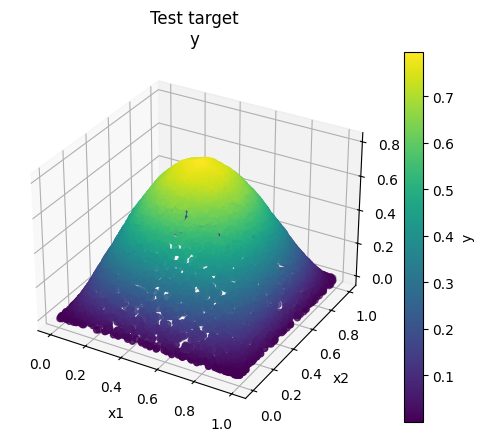

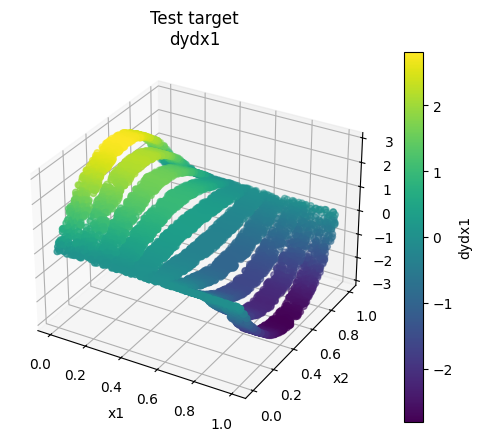

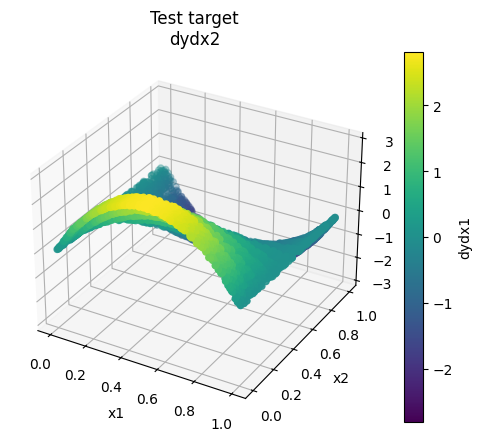

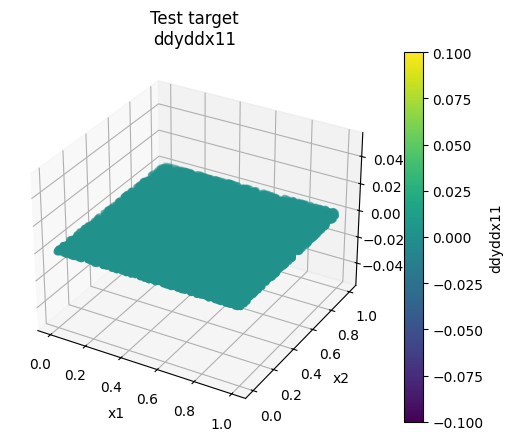

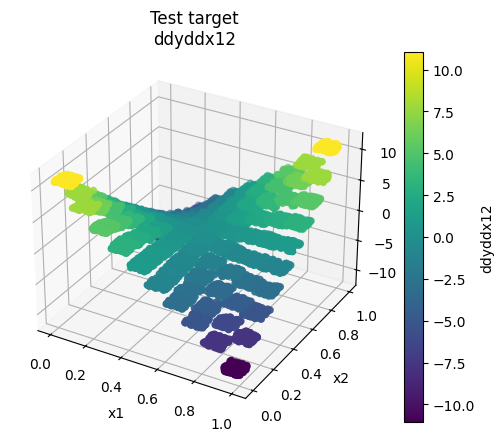

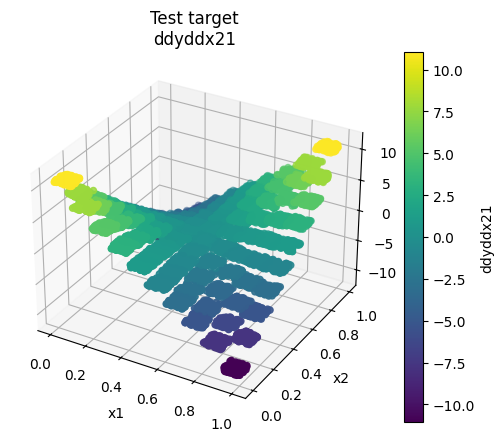

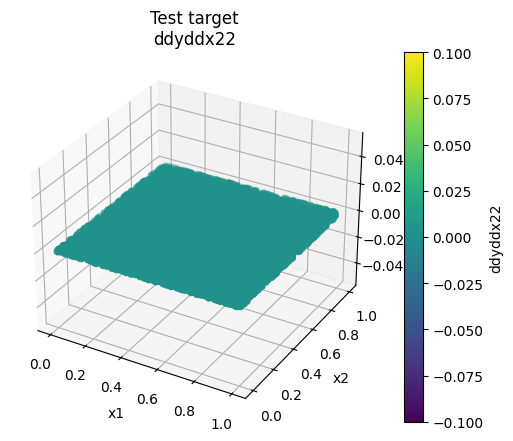

In [33]:
ref_model.visualize_dataset(test_set, "Test", is_second_order=True)

In [69]:
rng = jax.random.PRNGKey(42)



rand_svd_directions_ref_eights_1, eval_dir, k_dir, S_var = get_rand_SVD_directions(
                                    f=ref_model.ref_fn,
                                    k=2,
                                    x=test_set[0],
                                    key=rng,
                                    normalized=False
                                    )

w = rand_svd_directions_ref_eights_1[0]
#print(w)
w = w.reshape(ref_model.un_flattened_shape)
print("SVD direction shape:", w.shape)
print(w)



SVD direction shape: (2,)
[-1.0000001e+00 -1.9448731e-05]


S_var: [0.50000006 0.49999997]


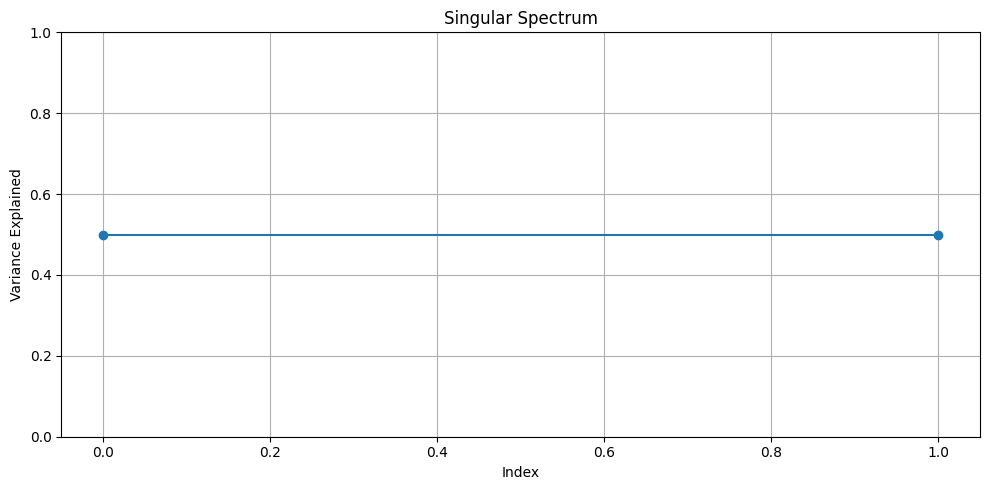

In [70]:

def plot_singular_spectrum(S_var):
    print("S_var:", S_var)
    plt.figure(figsize=(10, 5))
    plt.plot(S_var, marker='o')
    plt.title('Singular Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Variance Explained')
    plt.ylim(0, 1)
    plt.grid()
    plt.tight_layout()
    plt.show()

plot_singular_spectrum(S_var)

In [57]:
n_batches = 100
n_samples_per_batch = 64
keys = jax.random.split(ref_model.key, n_batches)

ws = []
xs = []
for i, batch_key in enumerate(keys):
    print(f"Batch {i+1}/{n_batches}")
    sample_batch=ref_model.sample(batch_key, n_samples=n_samples_per_batch)
    x = sample_batch[0]
    rand_svd_directions, eval_dir, k_dir, S_var = get_rand_SVD_directions(
                                    f=ref_model.ref_fn,
                                    k=2,
                                    x=x,
                                    key=batch_key,
                                    normalized=False
                                    )
    w=rand_svd_directions[0]
    #print(w)
    xs.append(x)
    ws.append(w)

Batch 1/100
Batch 2/100
Batch 3/100
Batch 4/100
Batch 5/100
Batch 6/100
Batch 7/100
Batch 8/100
Batch 9/100
Batch 10/100
Batch 11/100
Batch 12/100
Batch 13/100
Batch 14/100
Batch 15/100
Batch 16/100
Batch 17/100
Batch 18/100
Batch 19/100
Batch 20/100
Batch 21/100
Batch 22/100
Batch 23/100
Batch 24/100
Batch 25/100
Batch 26/100
Batch 27/100
Batch 28/100
Batch 29/100
Batch 30/100
Batch 31/100
Batch 32/100
Batch 33/100
Batch 34/100
Batch 35/100
Batch 36/100
Batch 37/100
Batch 38/100
Batch 39/100
Batch 40/100
Batch 41/100
Batch 42/100
Batch 43/100
Batch 44/100
Batch 45/100
Batch 46/100
Batch 47/100
Batch 48/100
Batch 49/100
Batch 50/100
Batch 51/100
Batch 52/100
Batch 53/100
Batch 54/100
Batch 55/100
Batch 56/100
Batch 57/100
Batch 58/100
Batch 59/100
Batch 60/100
Batch 61/100
Batch 62/100
Batch 63/100
Batch 64/100
Batch 65/100
Batch 66/100
Batch 67/100
Batch 68/100
Batch 69/100
Batch 70/100
Batch 71/100
Batch 72/100
Batch 73/100
Batch 74/100
Batch 75/100
Batch 76/100
Batch 77/100
Batch 78

In [58]:
from sklearn.cluster import DBSCAN
# cosine distance = 1 - cosine_similarity
db = DBSCAN(metric="cosine", eps=0.1, min_samples=5).fit(ws)
labels = db.labels_    # -1 = noise, 0,1,2… = cluster IDs
print("DBSCAN labels:", labels)

DBSCAN labels: [ 0  0  1  0  0  0  2  2  1  1  1  2  1  0  0  2  1  0  2  0  2  2  2  2
  0  1  2  2  2  1  0 -1  2  1  2  2  1  0  1  1  2  2  2  2  1  2  2  1
  0  0  2  2  2  1  2  2  0  1  0  2  2  2  0  2  2  2  2  2  2  2  2  1
  0  2  1  1  0  0  2  2  0  2  1  0  2  1  2  0  2  2  2  0  2  2  2  2
  2  2  2  0]


In [59]:
xs = jnp.array(xs)
xs = jnp.mean(xs, axis=1)  # average over batches
ws = jnp.array(ws)

print("xs shape:", xs.shape)
print("ws shape:", ws.shape)

xs shape: (100, 2)
ws shape: (100, 2)


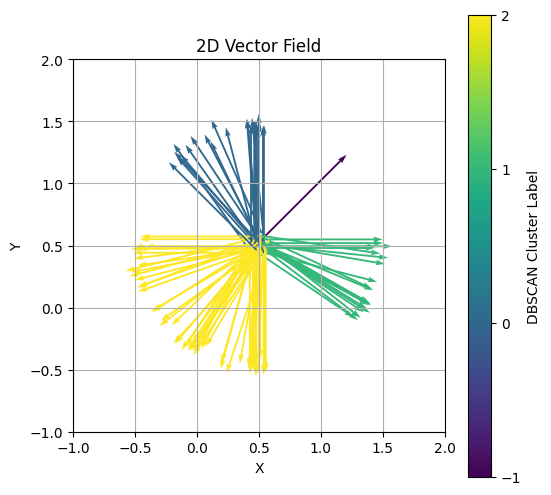

In [61]:
import numpy as np
import matplotlib.pyplot as plt


# Unpack
X = xs[:, 0]
Y = xs[:, 1]
U = ws[:, 0]
V = ws[:, 1]


fig, ax = plt.subplots(figsize=(6,6))

q = ax.quiver(
    X, Y,         # arrow locations
    U, V,         # arrow directions
    labels,
    cmap='viridis',  # color map for clusters
    angles='xy',  # treat (U,V) as cartesian
    scale_units='xy', 
    scale=1,      # lengths are in data units
    width=0.005
)

cbar = fig.colorbar(q, ax=ax, ticks=np.unique(labels))
cbar.set_label('DBSCAN Cluster Label')


plt.xlim(-1, 2)
plt.ylim(-1, 2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Vector Field')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()


# MNIST

In [40]:
import argparse
import jax
import jax.numpy as jnp
import jax.random as random
import jax.image as jim
import equinox as eqx
import optax
import tensorflow_datasets as tfds
from jaxtyping import Array, Float, PRNGKeyArray, ScalarLike


# ---------- Model (same as before) ----------
class CNN(eqx.Module):
    
    convs: list
    linear: eqx.nn.Linear
    #n_dims: int
    #un_flattened_shape: tuple

    def __init__(self, input_size: int, depth: int, base_channels: int, num_classes: int, key):
        keys = random.split(key, depth + 1)
        convs = []
        in_ch = 1
        for i in range(depth):
            out_ch = base_channels * (2**i)
            convs.append(eqx.nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, key=keys[i]))
            in_ch = out_ch

        # compute final spatial size exactly
        size = input_size
        for _ in range(depth):
            size = (size - 1) // 2 + 1
        final_size = size

        self.convs = convs
        self.linear = eqx.nn.Linear(in_ch * final_size * final_size, num_classes, key=keys[-1])
        #self.input_size = input_size
        
    def __call__(self, x):
        # x: (H, W, 1)
        x = jnp.transpose(x, (2, 0, 1))          # → (C,H,W)
        for conv in self.convs:
            x = conv(x)
            x = jax.nn.silu(x)
        x = x.reshape(-1)                       # flatten
        return self.linear(x)



class MNIST_ref(eqx.Module):

    key: PRNGKeyArray
    
    train_imgs: Float[Array, "train_size H W 1"] 
    test_imgs: Float[Array, "test_size H W 1"]
    train_lbls: Float[Array, "train_size"]
    test_lbls: Float[Array, "test_size"]

    cnn: CNN
    n_dims: int
    un_flattened_shape: tuple
    scale: float = 1.0  # default scale for MNIST
    target_class: int = 9  # default target class for MNIST

    
    def __init__(self, key, scale, target_class=9):
        self.key = key
        self.scale = scale
        self.target_class = target_class
        input_size = int(28 * scale)
        self.n_dims = input_size * input_size
        self.un_flattened_shape = (input_size, input_size, 1)

        self.key, cnn_key = random.split(self.key)
        self.cnn = CNN(
            input_size=int(28 * scale),
            depth=3,  # number of convolutional layers
            base_channels=32, # base number of channels in first conv layer
            num_classes=10,  # MNIST has 10 classes
            key=cnn_key
        )

        # Train the CNN on MNIST
        self.cnn = self.train(
            lr=1e-3, 
            batch_size=128, 
            epochs=10
        )



    def load_mnist(self):
        print("Loading MNIST dataset...")
        # load entire train & test splits as NumPy arrays
        ds = tfds.load("mnist", split=["train", "test"],
                       batch_size=-1, as_supervised=True)
        train_imgs, train_lbls = tfds.as_numpy(ds[0])
        test_imgs,  test_lbls  = tfds.as_numpy(ds[1])

        # normalize and resize
        train_imgs = train_imgs.astype(jnp.float32) / 255.0
        test_imgs  = test_imgs .astype(jnp.float32) / 255.0

        new_size = int(28 * self.scale)
        train_imgs = jim.resize(train_imgs, (train_imgs.shape[0], new_size, new_size, 1), method="bilinear")
        test_imgs  = jim.resize(test_imgs,  (test_imgs .shape[0], new_size, new_size, 1), method="bilinear")

        train_lbls = train_lbls.astype(jnp.int32)
        test_lbls  = test_lbls .astype(jnp.int32)

        #self.train_imgs = train_imgs
        #self.train_lbls = train_lbls
        #self.test_imgs  = test_imgs
        #self.test_lbls  = test_lbls
        return train_imgs, train_lbls, test_imgs, test_lbls

    def loss_fn(self, model, xb, yb):
        logits = jax.vmap(model)(xb)
        onehot = jax.nn.one_hot(yb, logits.shape[-1])
        return optax.softmax_cross_entropy(logits, onehot).mean()

    def accuracy(self, model, xb, yb):
        preds = jnp.argmax(jax.vmap(model)(xb), axis=-1)
        return jnp.mean(preds == yb)



    def train(self, lr, batch_size, epochs):

        train_imgs, train_lbls, test_imgs, test_lbls = self.load_mnist()
        self.train_imgs = train_imgs
        self.test_imgs = test_imgs
        self.train_lbls = train_lbls
        self.test_lbls = test_lbls
        
        num_train = train_imgs.shape[0]
        num_test  = test_imgs.shape[0]

        model = self.cnn
        optimizer = optax.adam(lr)
        opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

        @eqx.filter_jit
        def train_step(model, opt_state, xb, yb):
            loss, grads = eqx.filter_value_and_grad(self.loss_fn)(model, xb, yb)
            updates, opt_state = optimizer.update(grads, opt_state, model)
            model = eqx.apply_updates(model, updates)
            return model, opt_state

        print("Training reference model...")
        for epoch in range(1, epochs+1):
            print(f"Epoch {epoch}/{epochs}")
            # a) shuffle train set
            self.key, perm_key = random.split(self.key)
            perm = random.permutation(perm_key, num_train)
            train_imgs = train_imgs[perm]
            train_lbls = train_lbls[perm]

            # b) training by slicing
            for i in range(0, num_train, batch_size):
                xb = train_imgs[i:i+batch_size]
                yb = train_lbls[i:i+batch_size]
                model, opt_state = train_step(model, opt_state, xb, yb)

            # c) evaluation
            accs = []
            for i in range(0, num_test, batch_size):
                xb = test_imgs[i:i+batch_size]
                yb = test_lbls[i:i+batch_size]
                accs.append(self.accuracy(model, xb, yb))
            test_acc = jnp.stack(accs).mean()

            print(f" → test accuracy: {test_acc*100:.2f}%")

        return model


    

    def ref_fn(self, x_flat):
        x = x_flat.reshape(self.un_flattened_shape)  # reshape to (H, W, 1)
        logits = self.cnn(x)
        probs = jax.nn.softmax(logits, axis=-1)
        return probs[self.target_class]
    





    def get_test_set(self, n_samples):
        if n_samples > self.test_imgs.shape[0]:
            raise ValueError("Requested number of samples exceeds available test set size.")
        # return a subset of the test set
        indices = jnp.arange(self.test_imgs.shape[0])
        perm = random.permutation(self.key, indices)[:n_samples]

        x = self.test_imgs[perm]
        x_flat = x.reshape(n_samples, -1)  # flatten to (n_samples, n_dims)
        
        y_and_dy_fn = jax.value_and_grad(self.ref_fn)
        y, dydx= jax.vmap(y_and_dy_fn)(x_flat)  # y: (n_samples,), dy: (n_samples, n_dims)
        #print("y shape: ", y.shape)
        #print("dy shape: ", dy.shape)

        ddyddx = jax.vmap(jax.hessian(self.ref_fn))(x_flat)
        #print("H_full shape: ", H_full.shape)
        
        return x_flat, y, dydx, ddyddx  
    


    def sample(self, key, n_samples):

        if n_samples > self.train_imgs.shape[0]:
            raise ValueError("Requested number of samples exceeds available train set size.")
        
        # return a subset of the train set
        indices = jnp.arange(self.train_imgs.shape[0])
        perm = random.permutation(key, indices)[:n_samples]

        x = self.train_imgs[perm]
        x_flat = x.reshape(n_samples, -1)  # flatten to (n_samples, n_dims)
        
        y_and_dy_fn = jax.value_and_grad(self.ref_fn)
        y, dydx= jax.vmap(y_and_dy_fn)(x_flat)  # y: (n_samples,), dy: (n_samples, n_dims)
        
        return x_flat, y, dydx
    



In [41]:
key = random.PRNGKey(0)
ref_model = MNIST_ref(
    key=key, 
    scale=0.5,
    target_class=9
)

Loading MNIST dataset...
Training reference model...
Epoch 1/10
 → test accuracy: 94.58%
Epoch 2/10
 → test accuracy: 96.88%
Epoch 3/10
 → test accuracy: 97.62%
Epoch 4/10
 → test accuracy: 98.02%
Epoch 5/10
 → test accuracy: 97.97%
Epoch 6/10
 → test accuracy: 98.34%
Epoch 7/10
 → test accuracy: 98.21%
Epoch 8/10
 → test accuracy: 98.56%
Epoch 9/10
 → test accuracy: 98.18%
Epoch 10/10
 → test accuracy: 98.49%


In [47]:
test_set = ref_model.get_test_set(100)
print("Test shapes")
print("test x: ", test_set[0].shape)
print("test y: ", test_set[1].shape)
print("test dydx: ", test_set[2].shape)
print("test ddyddx: ", test_set[3].shape)

print("")
print("Sample batch shapes")
sample_batch = ref_model.sample(key, 256)
print("train x: ", sample_batch[0].shape)
print("train y: ", sample_batch[1].shape)
print("train dydx: ", sample_batch[2].shape)

Test shapes
test x:  (100, 196)
test y:  (100,)
test dydx:  (100, 196)
test ddyddx:  (100, 196, 196)

Sample batch shapes
train x:  (256, 196)
train y:  (256,)
train dydx:  (256, 196)


In [52]:
x_example = test_set[0][1]
print("Example input shape:", x_example.shape)

Example input shape: (196,)


In [53]:
import numpy as np
import matplotlib.pyplot as plt

# suppose `img` is your array of shape (28,28,1), e.g.:
# img = train_imgs[0]    # from the MNIST arrays you loaded

def plot_img(img):
    
    if len(img.shape) == 1:
        side_length = int(jnp.sqrt(img.shape[0]))
        gray = img.reshape(side_length, side_length)
    else:
        gray = np.squeeze(img)    # now shape (28,28)
    
    plt.figure(figsize=(3,3))
    plt.imshow(gray, cmap="gray", interpolation="nearest")
    plt.axis("off")           # turn off axis ticks
    plt.show()
    

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_img_colored(img, figsize=(3,3), interpolation="nearest"):
    
    if len(img.shape) == 1:
        side_length = int(jnp.sqrt(img.shape[0]))
        arr = img.reshape(side_length, side_length)
    else:
        arr = np.squeeze(img)
    # create a 3‐color colormap: red at low end, grey at zero, green at high end
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "red_grey_green", 
        [("red"), ("lightgrey"), ("green")],
        N=256
    )
    # center the color scaling at zero
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    
    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap=cmap, norm=norm, interpolation=interpolation)
    plt.axis("off")
    plt.show()


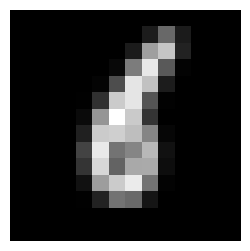

In [55]:
plot_img(x_example)

In [56]:
ref_fn = ref_model.ref_fn
pred = ref_fn(x_example)
print("Prediction for example input:", pred)

Prediction for example input: 4.6938814e-07


Gradient at example input shape: (196,)


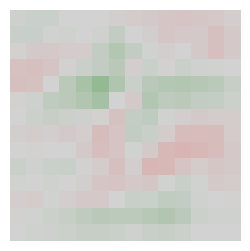

In [57]:
grad = jax.grad(ref_fn)(x_example)
print("Gradient at example input shape:", grad.shape)
grad = grad/jnp.linalg.norm(grad) 
plot_img_colored(grad)

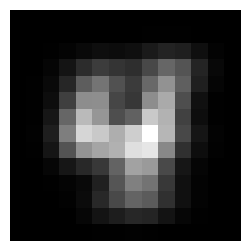

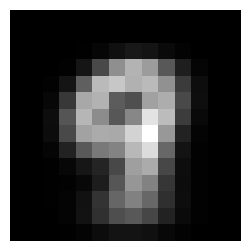

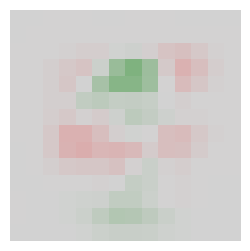

In [58]:
eights = ref_model.test_imgs[ref_model.test_lbls == 4]
eight = eights.mean(axis=0)
plot_img(eight)

nines = ref_model.test_imgs[ref_model.test_lbls == 9]
nine = nines.mean(axis=0)
plot_img(nine)

diff = nine - eight
plot_img_colored(diff)

Sample images with label 8 shape: (982, 14, 14, 1)
Batch gradient shape: (982, 14, 14, 1)
Mean gradient shape: (14, 14, 1)


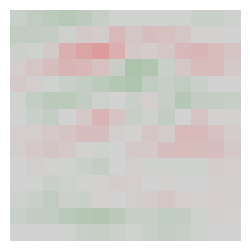

In [59]:
# get test images where label is 8
sample_imgs = ref_model.test_imgs[ref_model.test_lbls == 4]
print("Sample images with label 8 shape:", sample_imgs.shape)

grads = jax.vmap(jax.grad(ref_fn))(sample_imgs)
print("Batch gradient shape:", grads.shape)
grad = jnp.mean(grads, axis=0)
print("Mean gradient shape:", grad.shape)
grad = grad / jnp.linalg.norm(grad)  # normalize
plot_img_colored(grad)

In [257]:
print(ref_model.n_dims)

484


SVD direction shape: (14, 14, 1)


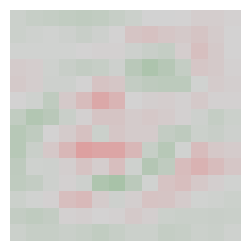

In [60]:
rng = random.PRNGKey(42)


sample_imgs = ref_model.test_imgs[ref_model.test_lbls == 8]
sample_imgs = sample_imgs[:200]  # use only the first 200 samples for SVD directions

x_flat = sample_imgs.reshape(sample_imgs.shape[0], -1)  # (batch_size, n_dims)
#x_flat = x_flat[:100]  # use only the first 100 samples for SVD directions



rand_svd_directions_ref_eights_1, eval_dir, k_dir, S_var = get_rand_SVD_directions(
                                    f=ref_fn,
                                    x=x_flat,
                                    key=rng,
                                    normalized=False
                                    )

w = rand_svd_directions_ref_eights_1[0]
#print(w)
w = w.reshape(ref_model.un_flattened_shape)
print("SVD direction shape:", w.shape)
plot_img_colored(w)



S_var: [0.6672677  0.18699262 0.10330865 0.01360232 0.01036114 0.006633
 0.0051127  0.00422752 0.00137089 0.00112351]


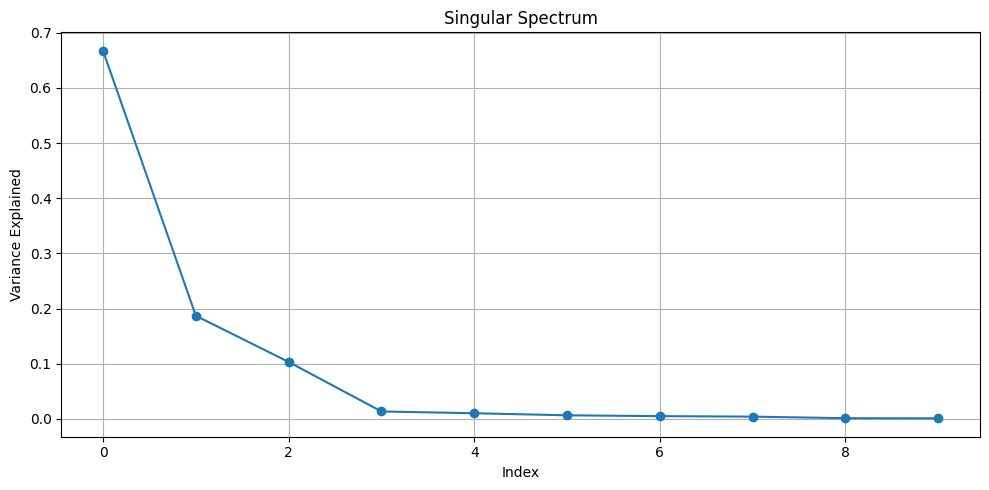

In [ ]:

def plot_singular_spectrum(S_var):
    print("S_var:", S_var)
    plt.figure(figsize=(10, 5))
    plt.plot(S_var, marker='o')
    plt.title('Singular Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Variance Explained')
    plt.ylim(0, 1)
    plt.grid()
    plt.tight_layout()
    plt.show()

plot_singular_spectrum(S_var)

In [62]:
import jax.numpy as jnp

def cosine_similarity_eigenspectrums(spec1: jnp.ndarray,
                                     spec2: jnp.ndarray,
                                     eps: float = 1e-8) -> jnp.ndarray:
    """
    Compute the cosine similarity between two eigenspectrums.

    Each spectrum is given as an array of shape (r, dim, dim). We
    flatten each (dim, dim) slice to a vector of length dim*dim and
    compute the per‐slice cosine similarity.

    Args:
        spec1: jnp.ndarray of shape (r, dim, dim)
        spec2: jnp.ndarray of shape (r, dim, dim)
        eps:   small constant to avoid division by zero

    Returns:
        sims:  jnp.ndarray of shape (r,)
               sims[i] = (spec1[i]·spec2[i]) /
                         (‖spec1[i]‖ ‖spec2[i]‖ + eps)
    """
    # ensure the two inputs have the same shape
    assert spec1.shape == spec2.shape, "Input spectra must have the same shape"

    r = spec1.shape[0]
    # flatten each (dim, dim) slice to length dim*dim
    v1 = spec1.reshape(r, -1)
    v2 = spec2.reshape(r, -1)

    # dot products between corresponding slices
    dot = jnp.sum(v1 * v2, axis=1)
    # norms of each slice
    norm1 = jnp.linalg.norm(v1, axis=1)
    norm2 = jnp.linalg.norm(v2, axis=1)

    # cosine similarities
    return dot / (norm1 * norm2 + eps)


In [63]:
rng = random.PRNGKey(42)


sample_imgs = test_imgs[test_lbls == 8]
sample_imgs = sample_imgs[200:400]  # use only the first 200 samples for SVD directions

x_flat = sample_imgs.reshape(sample_imgs.shape[0], -1)  # (batch_size, n_dims)
#x_flat = x_flat[:100]  # use only the first 100 samples for SVD directions



rand_svd_directions_ref_eights_2, eval_dir, k_dir, S_var = get_rand_SVD_directions(
                                    f=ref_fn,
                                    x=x_flat,
                                    key=rng,
                                    normalized=False
                                    )

w = rand_svd_directions_ref_eights_2[0]
#print(w)
w = w.reshape(ref_model.un_flattened_shape)
print("SVD direction shape:", w.shape)
plot_img_colored(w)



NameError: name 'test_imgs' is not defined

In [264]:
sim = cosine_similarity_eigenspectrums(    rand_svd_directions_ref_eights_1,
    rand_svd_directions_ref_eights_2
)
print("Cosine similarity between eigenspectrums:", sim)

Cosine similarity between eigenspectrums: [ 0.9058423  -0.63761646 -0.18032475  0.21297114 -0.01482972 -0.10068499
  0.2667733   0.01076553  0.1368962   0.46605092]


SVD direction shape: (22, 22, 1)


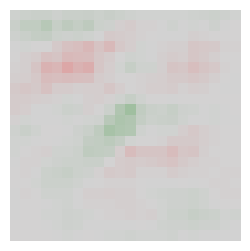

In [276]:
rng = random.PRNGKey(42)


sample_imgs = test_imgs[test_lbls == 7]
sample_imgs = sample_imgs[200:400]  # use only the first 200 samples for SVD directions

x_flat = sample_imgs.reshape(sample_imgs.shape[0], -1)  # (batch_size, n_dims)
#x_flat = x_flat[:100]  # use only the first 100 samples for SVD directions



rand_svd_directions_ref_sevens_1, eval_dir, k_dir, S_var = get_rand_SVD_directions(
                                    f=ref_fn,
                                    x=x_flat,
                                    key=rng,
                                    normalized=False
                                    )

w = rand_svd_directions_ref_sevens_1[0]
#print(w)
w = w.reshape(ref_model.un_flattened_shape)
print("SVD direction shape:", w.shape)
plot_img_colored(w)



In [271]:
sim2 = cosine_similarity_eigenspectrums(    rand_svd_directions_ref_eights_1,
    rand_svd_directions_ref_sevens_1
)
print("Cosine similarity between eigenspectrums (8s vs 7s):", sim2)

Cosine similarity between eigenspectrums (8s vs 7s): [ 0.36799192 -0.11892737  0.14071602  0.07822476  0.12641574  0.3542467
 -0.11396859 -0.0694261   0.09201857 -0.20304583]
